In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
print(df.shape)
print(df.head())
print(df.info())
print(df.describe)

(150, 6)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width

In [4]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


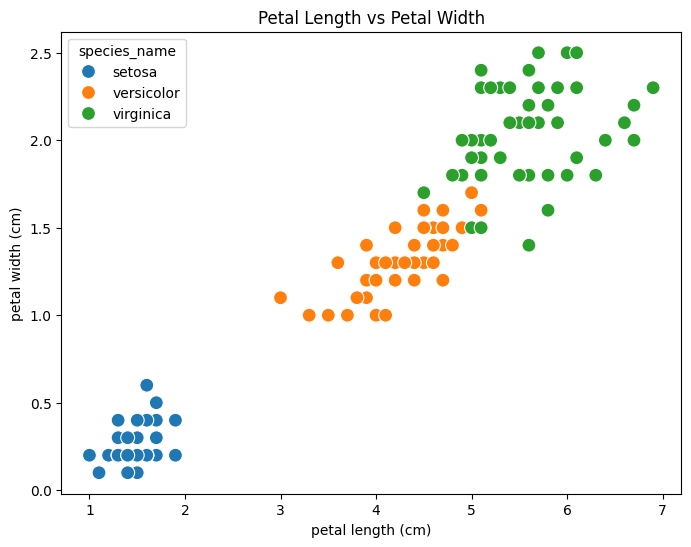

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='petal length (cm)',y='petal width (cm)',hue='species_name',data=df,s=100)
plt.title("Petal Length vs Petal Width")
plt.show()

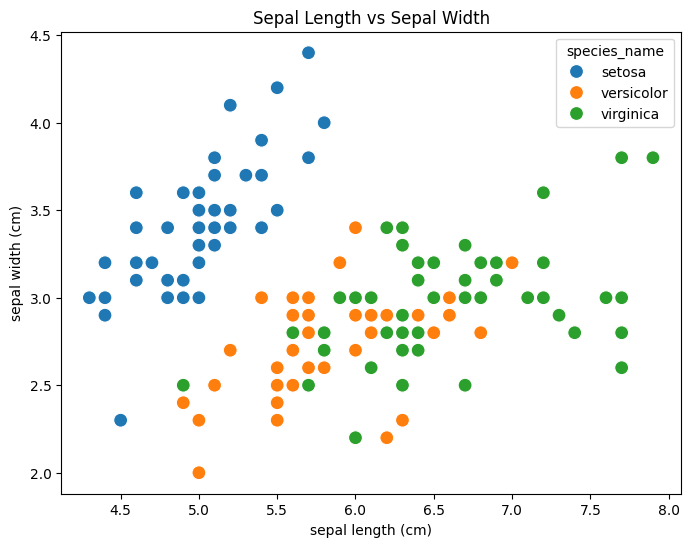

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='sepal length (cm)',y='sepal width (cm)',hue='species_name',data=df,s=100)
plt.title("Sepal Length vs Sepal Width")
plt.show()

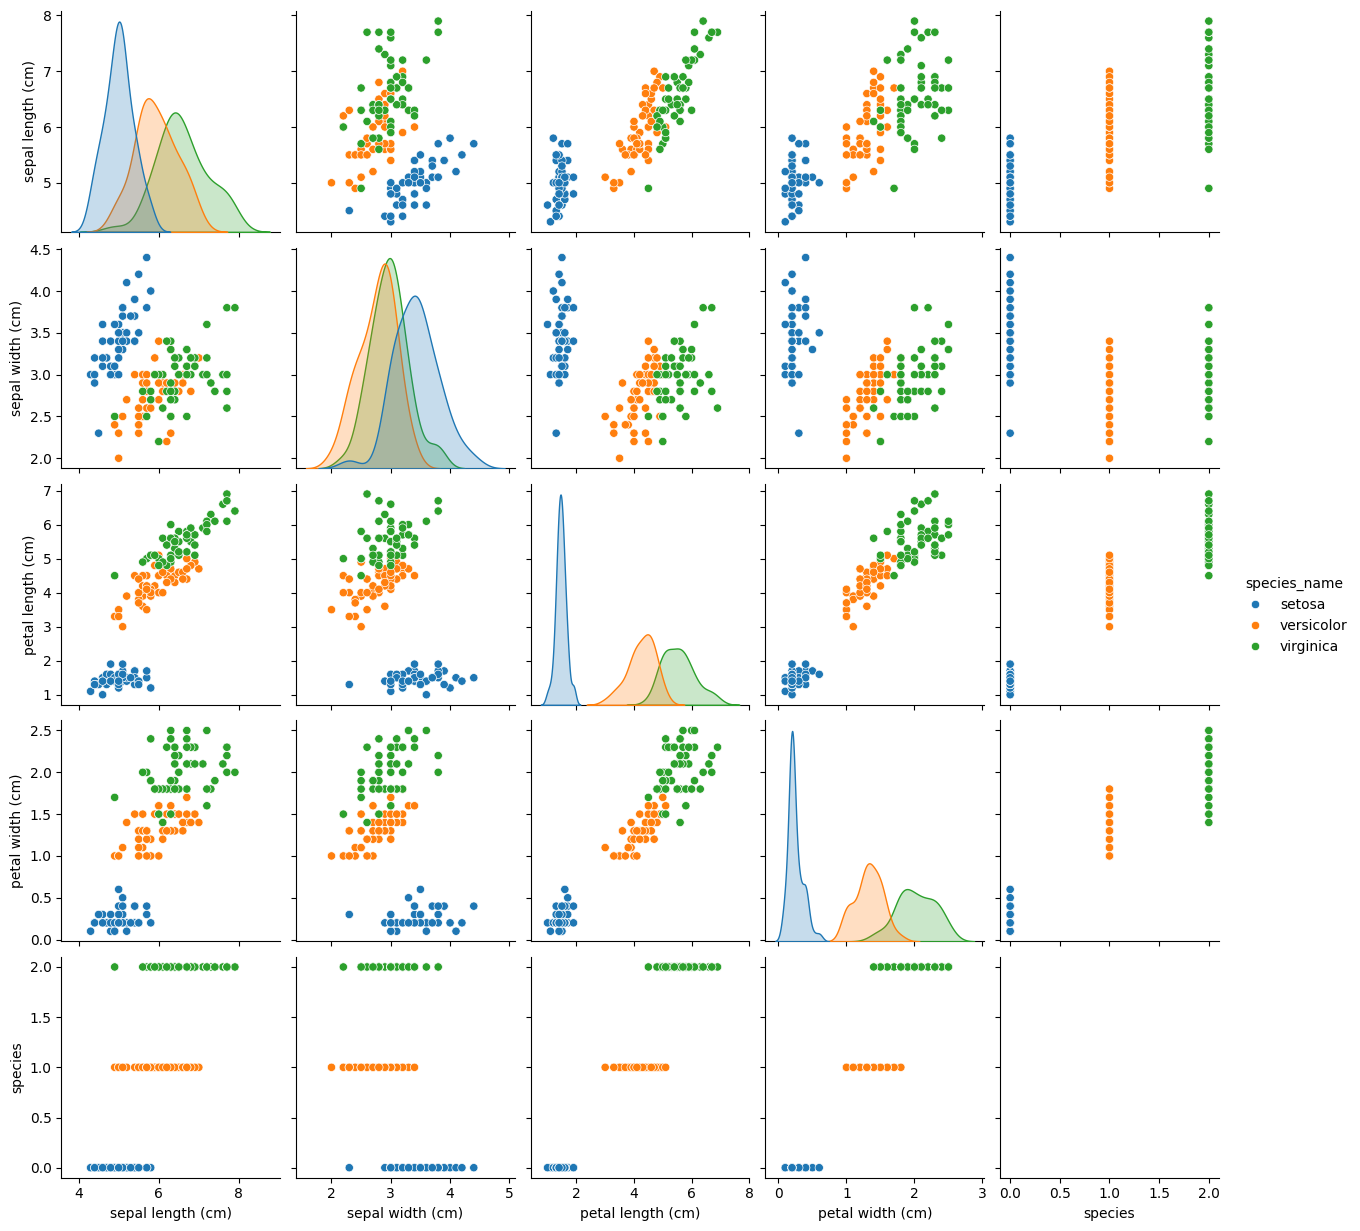

In [7]:
sns.pairplot(df,hue='species_name')
plt.show()

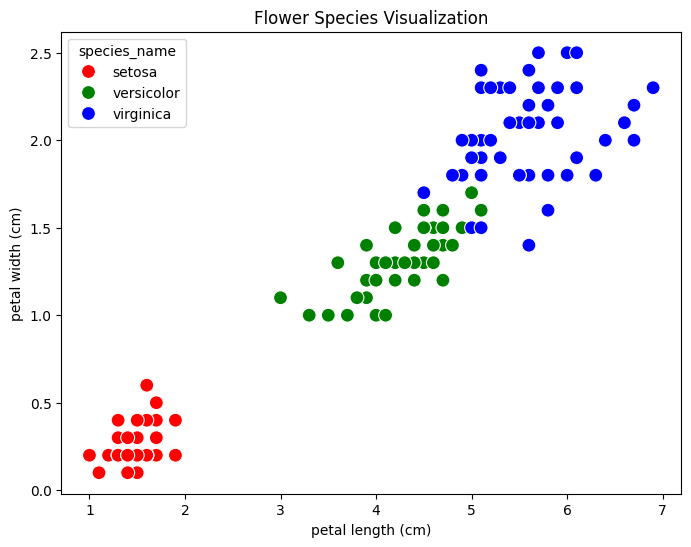

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='petal length (cm)',y='petal width (cm)',hue='species_name',palette=['red', 'green', 'blue'],data=df,s=100)
plt.title("Flower Species Visualization")
plt.show()

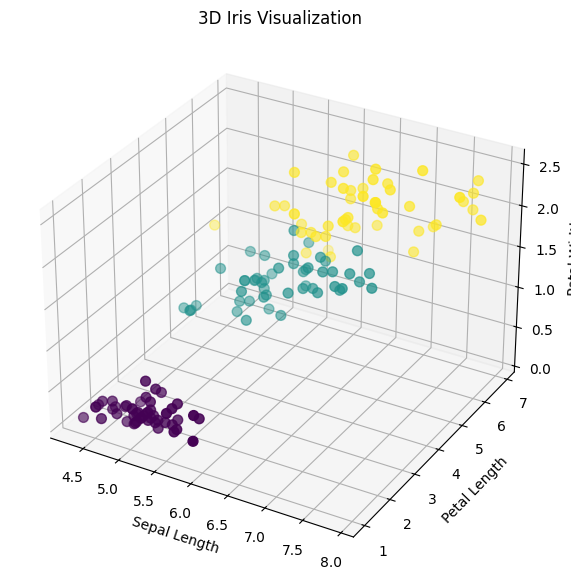

In [9]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['sepal length (cm)'],df['petal length (cm)'],df['petal width (cm)'],c=df['species'],s=50)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Petal Length')
ax.set_zlabel('Petal Width')
plt.title("3D Iris Visualization")
plt.show()

In [10]:
X = df.drop(columns=['species', 'species_name'])
y = df['species']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [14]:
log_pred = log_model.predict(X_test)

In [15]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

In [17]:
svm_pred = svm_model.predict(X_test)

In [18]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [20]:
knn_pred = knn_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [23]:
log_accuracy = accuracy_score(y_test,log_pred)
print("Logistic Regression Accuracy:",log_accuracy)

Logistic Regression Accuracy: 1.0


In [24]:
log_cm = confusion_matrix(y_test,log_pred)
print(log_cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


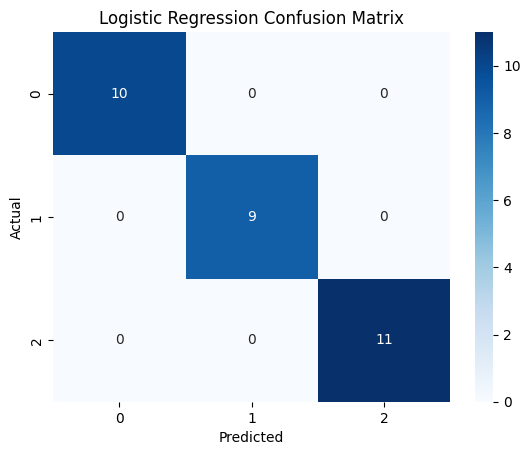

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(log_cm,annot=True,fmt='d',cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [27]:
svm_accuracy = accuracy_score(y_test,svm_pred)
print("SVM Accuracy:",svm_accuracy)

SVM Accuracy: 1.0


In [28]:
svm_cm = confusion_matrix(y_test,svm_pred)
print(svm_cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [29]:
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:",knn_accuracy)

KNN Accuracy: 1.0


In [30]:
knn_cm = confusion_matrix(y_test,knn_pred)
print(knn_cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [31]:
print("Logistic Regression Accuracy:",log_accuracy)
print("SVM Accuracy:",svm_accuracy)
print("KNN Accuracy:",knn_accuracy)

Logistic Regression Accuracy: 1.0
SVM Accuracy: 1.0
KNN Accuracy: 1.0
